In [91]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
pumpkins=pd.read_csv('../../LogisticRegression/logisticRegressionPumpkins/US-pumpkins.csv')
#Use the 'head()' function to view the first five rows
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [78]:
#Check if there is missing data in the current dataframe
pumpkins.isnull()
##
pumpkins.isnull().sum()


Package       0
Low Price     0
High Price    0
Date          0
dtype: int64

In [63]:
#The expression ':' in the case below means "all rows".
columns_to_select=["Package","Low Price","High Price","Date"]
#Select only the columns you need,using the 'loc' function which
#extracts from the original dataframe a group of rows(passed as first parameter) and
#columns (passed as second parameter)
pumpkins=pumpkins.loc[:,columns_to_select]
pumpkins.head()

,Package,Low Price,High Price,Date
0,24 inch bins,270.0,280.0,4/29/17
1,24 inch bins,270.0,280.0,5/6/17
2,24 inch bins,160.0,160.0,9/24/16
3,24 inch bins,160.0,160.0,9/24/16
4,24 inch bins,90.0,100.0,11/5/16


In [64]:
#How to determine the average price of a pumpkin in a given month.What columns would you pick
#for this task?

#To calculate  the average
price=(pumpkins["Low Price"]+pumpkins["High Price"])/2
month=pd.DatetimeIndex(pumpkins["Date"]).month
# print(month)
#Now,copy your converted data into a fresh Pandas dataframe
new_pumpkins=pd.DataFrame({'Month':month,
                           'Package':pumpkins['Package'],
                           'Low Price':pumpkins['Low Price'],
                           'High Price':pumpkins['High Price'],
                           'Price':price})

In [65]:
##Filterin Data
pumpkins=pumpkins[pumpkins['Package'].str.contains('bushel',case=True,regex=True)]#return dataTable
pumpkins.head()



,Package,Low Price,High Price,Date
70,1 1/9 bushel cartons,15.0,15.0,9/24/16
71,1 1/9 bushel cartons,18.0,18.0,9/24/16
72,1 1/9 bushel cartons,18.0,18.0,10/1/16
73,1 1/9 bushel cartons,17.0,17.0,10/1/16
74,1 1/9 bushel cartons,15.0,15.0,10/8/16


In [80]:
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'),'Price']=price/(1+1/9)
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/2'),'Price']=price/(1/2)


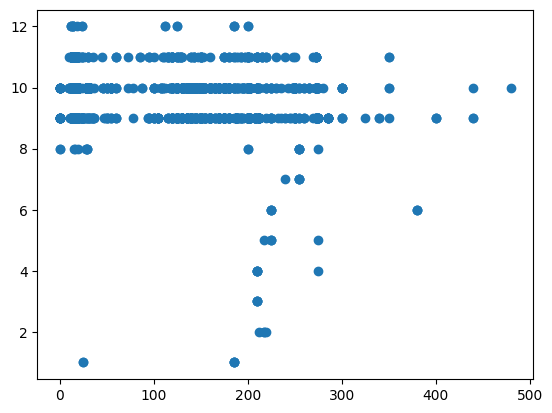

In [81]:
price=new_pumpkins.Price
month=new_pumpkins.Month
plt.scatter(price,month)
plt.show()

In [82]:
new_pumpkins.head()


,Month,Package,Low Price,High Price,Price
0,4,24 inch bins,270.0,280.0,275.0
1,5,24 inch bins,270.0,280.0,275.0
2,9,24 inch bins,160.0,160.0,160.0
3,9,24 inch bins,160.0,160.0,160.0
4,11,24 inch bins,90.0,100.0,95.0


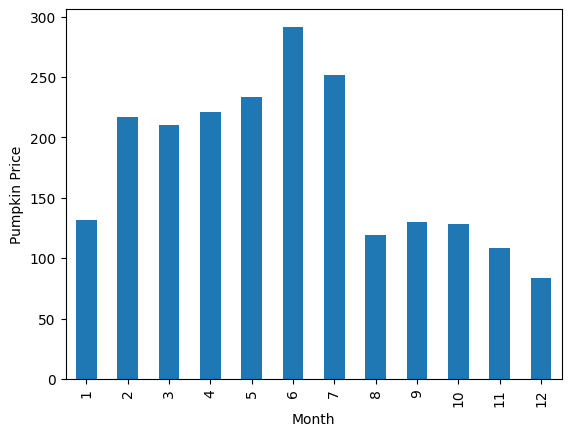

In [83]:
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')
plt.ylabel('Pumpkin Price')
plt.show()


In [85]:
# pumpkins.isnull().sum()
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt- datetime(dt.year,1,1)).days)


In [107]:
new_pumpkins=pd.DataFrame(
    {'Month':month,
     'DayOfYear':day_of_year,
     'Variety':pumpkins['Variety'],
     'City':pumpkins['City'],
     'Package':pumpkins['Package'],
     'Low Price':pumpkins['Low Price'],
     'High Price':pumpkins['High Price'],
     'Price':price
     }
)

KeyError: 'City'

In [106]:
print(new_pumpkins['Month'].corr(new_pumpkins['Price']))
print(new_pumpkins['day_of_year'].corr(new_pumpkins['Price']))



-0.139802232149018


KeyError: 'day_of_year'